#**Digitization Techniques**


Purpose:  Because machine learning models usually dont handle text directly and need numerical inputs.

# Encoding
Encoding is the process of assigning numbers to text and graphical characters

**Frequency-based encoding**

*  Frequency-based encoding means words are ranked and indexed based on how often they appear in the corpus.


Let us consider the texts : 'I like machine learning' and 'I like deep learning'

Can we assign frequency based tokenization for each words

* I =
* like =
* machine =
* learning =
* deep =

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
# Sample text data
#texts = ["I like machine learning ", "I like deep learning"]
texts = ["I like like machine learning learning", "I like like deep learning"]

# Initialize and fit the tokenizer
tokenizer = Tokenizer()
tokenizer.fit_on_texts(texts)

# Convert text to sequences of numbers
sequences = tokenizer.texts_to_sequences(texts)
print(sequences)

[[3, 1, 1, 4, 2, 2], [3, 1, 1, 5, 2]]


#Label Encoding
Assigns a unique integer to each category (e.g., red=1, blue=2).

Limitation: ANNs may misinterpret integers as ordinal values (e.g., red < blue).

# Mean Encoding

Replaces categories with the mean of the target variable.

In [ ]:
import pandas as pd

# Sample data with a categorical feature and target
data = pd.DataFrame({
    'category': ['A', 'B', 'A', 'C', 'B', 'C'],
    'target': [10, 20, 15, 30, 25, 35]
})

# Compute mean encoding
mean_encoding = data.groupby('category')['target'].mean().to_dict()
data['category_encoded'] = data['category'].map(mean_encoding)

print("Target Encoding Result:")
print(data)

Target Encoding Result:
  category  target  category_encoded
0        A      10              12.5
1        B      20              22.5
2        A      15              12.5
3        C      30              32.5
4        B      25              22.5
5        C      35              32.5


#Ordinal Encoding

Similar to tokenization but specifically designed for categorical features that have an intrinsic order.

**When to Use:** Useful when dealing with ordinal data (e.g., size: Small, Medium, Large) where the order matters but the scale isn’t necessarily linear.

Assigns numerical values to categories based on their order, e.g., Small=1, Medium=2, Large=3.

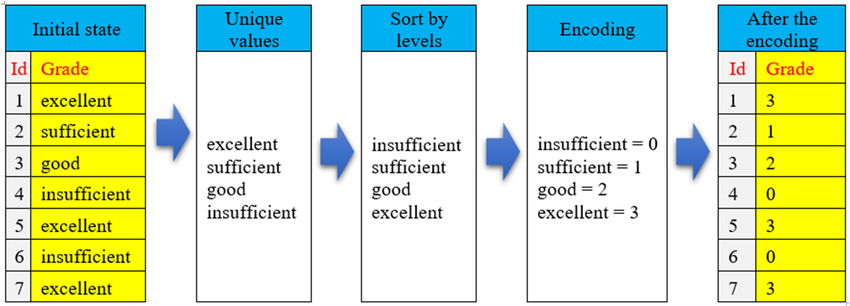

**Example:**

Let’s assume we have a dataset that contains a column called experience_level that captures the skill level of employees: Beginner, Intermediate, and Expert. These categories have a clear order, so we can apply ordinal encoding.




We’ll assign numerical values to each experience level based on their order:

    Beginner: 0
    Intermediate: 1
    Expert: 2

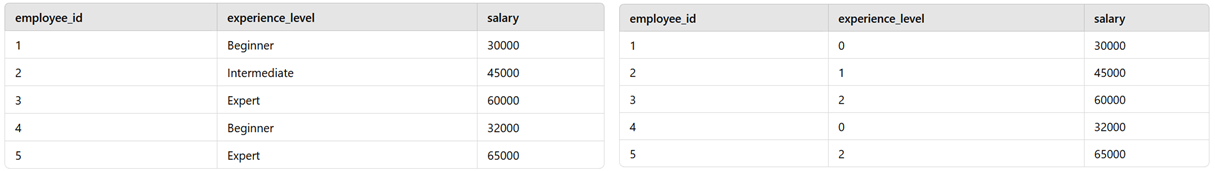

In [ ]:
import pandas as pd
from sklearn.preprocessing import OrdinalEncoder

# dataset creation
data = {
    'employee_id': [1, 2, 3, 4, 5],
    'experience_level': ['Beginner', 'Intermediate', 'Expert', 'Beginner', 'Expert'],
    'salary': [30000, 45000, 60000, 32000, 65000]
}

# Create a DataFrame
df = pd.DataFrame(data)

# Display original data
print("Original Data:")
print(df)

Original Data:
   employee_id experience_level  salary
0            1         Beginner   30000
1            2     Intermediate   45000
2            3           Expert   60000
3            4         Beginner   32000
4            5           Expert   65000


In [ ]:
# Apply Ordinal Encoding directly to the 'experience_level' column
 encoder = OrdinalEncoder(categories=[['Beginner', 'Intermediate', 'Expert']])  # Define the order
# what happens if the order we give is ['Intermediate', 'Beginner', 'Expert']??
#encoder = OrdinalEncoder(categories=[['Intermediate', 'Beginner', 'Expert']])

df['experience_level'] = encoder.fit_transform(df[['experience_level']]).astype(int)  # Convert to integer

# Display transformed data with replaced values
print("\nData with Ordinal Encoding (Replaced with Integers):")
print(df)


Data with Ordinal Encoding (Replaced with Integers):
   employee_id  experience_level  salary
0            1                 1   30000
1            2                 0   45000
2            3                 2   60000
3            4                 1   32000
4            5                 2   65000


# One hot Encoding
 A technique that creates a binary (0 or 1) column for each category in a categorical variable. Each category has its own unique column, and the corresponding value for that category is marked as 1, while the others remain 0.


*  **When to Use**: Use one-hot encoding when there’s no ordinal relationship between categories. It works well for nominal data, where categories are unordered.
*  Each category gets its own column, and the values are 1 if the instance belongs to that category and 0 otherwise.

**Drop first logic:** One category is dropped because its presence can be inferred from the values of the other categories. Dropping one category ensures that there is no redundant or correlated information while keeping all necessary data intact.


**Example:**

Given the data: ['SUV', 'Sedan', 'Sedan', 'SUV', 'SUV']

The unique values in the model column are ['Sedan', 'SUV'] (in alphabetical order). So, 'Sedan' is dropped since 'Sedan' comes first alphabetically compared to 'SUV'.

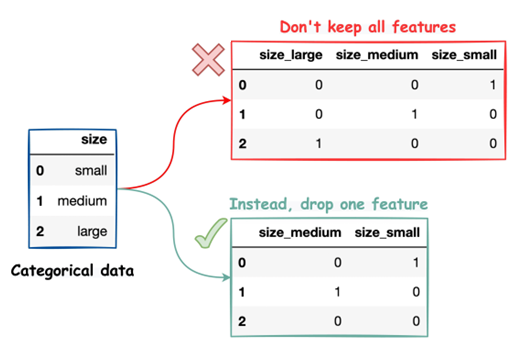


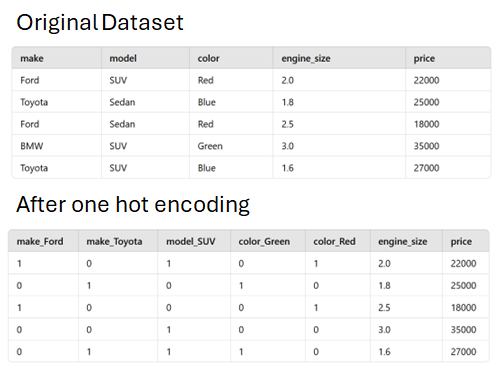

In [ ]:
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Sample dataset
data = {
    'make': ['Ford', 'Toyota', 'Ford', 'BMW', 'Toyota'],
    'model': ['SUV', 'Sedan', 'Sedan', 'SUV', 'SUV'],
    'color': ['Red', 'Blue', 'Red', 'Green', 'Blue'],
    'engine_size': [2.0, 1.8, 2.5, 3.0, 1.6],
    'price': [22000, 25000, 18000, 35000, 27000]
}

# Create DataFrame
df = pd.DataFrame(data)

# Define the ColumnTransformer with OneHotEncoder
column_transformer = ColumnTransformer(
    transformers=[
        ('encoder', OneHotEncoder(drop='first'), ['make', 'model', 'color'])
    ],
    remainder='passthrough'
)

# Apply the transformation
transformed_data = column_transformer.fit_transform(df.drop('price', axis=1))

# Create DataFrame for transformed data (including new column names)
transformed_columns = column_transformer.get_feature_names_out()
df_transformed = pd.DataFrame(transformed_data, columns=transformed_columns)

# Display transformed data
print("\nTransformed Data (One-Hot Encoded):")
print(df_transformed)


Transformed Data (One-Hot Encoded):
   encoder__make_Ford  encoder__make_Toyota  encoder__model_Sedan  \
0                 1.0                   0.0                   0.0   
1                 0.0                   1.0                   1.0   
2                 1.0                   0.0                   1.0   
3                 0.0                   0.0                   0.0   
4                 0.0                   1.0                   0.0   

   encoder__color_Green  encoder__color_Red  remainder__engine_size  
0                   0.0                 1.0                     2.0  
1                   0.0                 0.0                     1.8  
2                   0.0                 1.0                     2.5  
3                   1.0                 0.0                     3.0  
4                   0.0                 0.0                     1.6  


# Standardizing the data

Standardization is a preprocessing technique used in data analysis and machine learning to transform features in a dataset so that they have a mean of 0 and a standard deviation of 1.

*  Equal Contribution of Features: If features have different scales (e.g., age in years vs. income in thousands), features with larger ranges can disproportionately influence the model's performance. Standardization ensures that all features contribute equally.

*  Example of Standardization

Consider a dataset with two features: height (in cm) and weight (in kg). Without standardization, the height may range from 150 cm to 200 cm, while the weight may range from 40 kg to 100 kg. If we apply a machine learning algorithm directly, the model may place more importance on height due to its larger range.

# Case Study 1: Prediction of used car pricing


In [ ]:
# Importing necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import tensorflow as tf

# Upload Excel dataset
from google.colab import files
uploaded = files.upload()

# Load the dataset into pandas DataFrame
file_name = list(uploaded.keys())[0]  # Get the uploaded file name
df = pd.read_excel(file_name)

# Check for missing values and data types
print(df.info())
print(df.head())

# Splitting features and target
X = df[['make', 'model', 'year', 'kilometers', 'color', 'engine_capacity']]
y = df['price']



Saving used_car_prices.xlsx to used_car_prices (2).xlsx
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   make             1000 non-null   object 
 1   model            1000 non-null   object 
 2   year             1000 non-null   int64  
 3   kilometers       1000 non-null   int64  
 4   color            1000 non-null   object 
 5   engine_capacity  1000 non-null   float64
 6   price            1000 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 54.8+ KB
None
       make  model  year  kilometers   color  engine_capacity         price
0       BMW  Coupe  2016      145643   Black              3.6  24227.698594
1  Mercedes  Coupe  2021      108255   Black              1.3  22868.222368
2      Ford  Coupe  2010      189013  Silver              2.5  11486.800208
3  Mercedes  Coupe  2017       58005  Silver         

# Data pre-processing

Standardization and one hot encoding

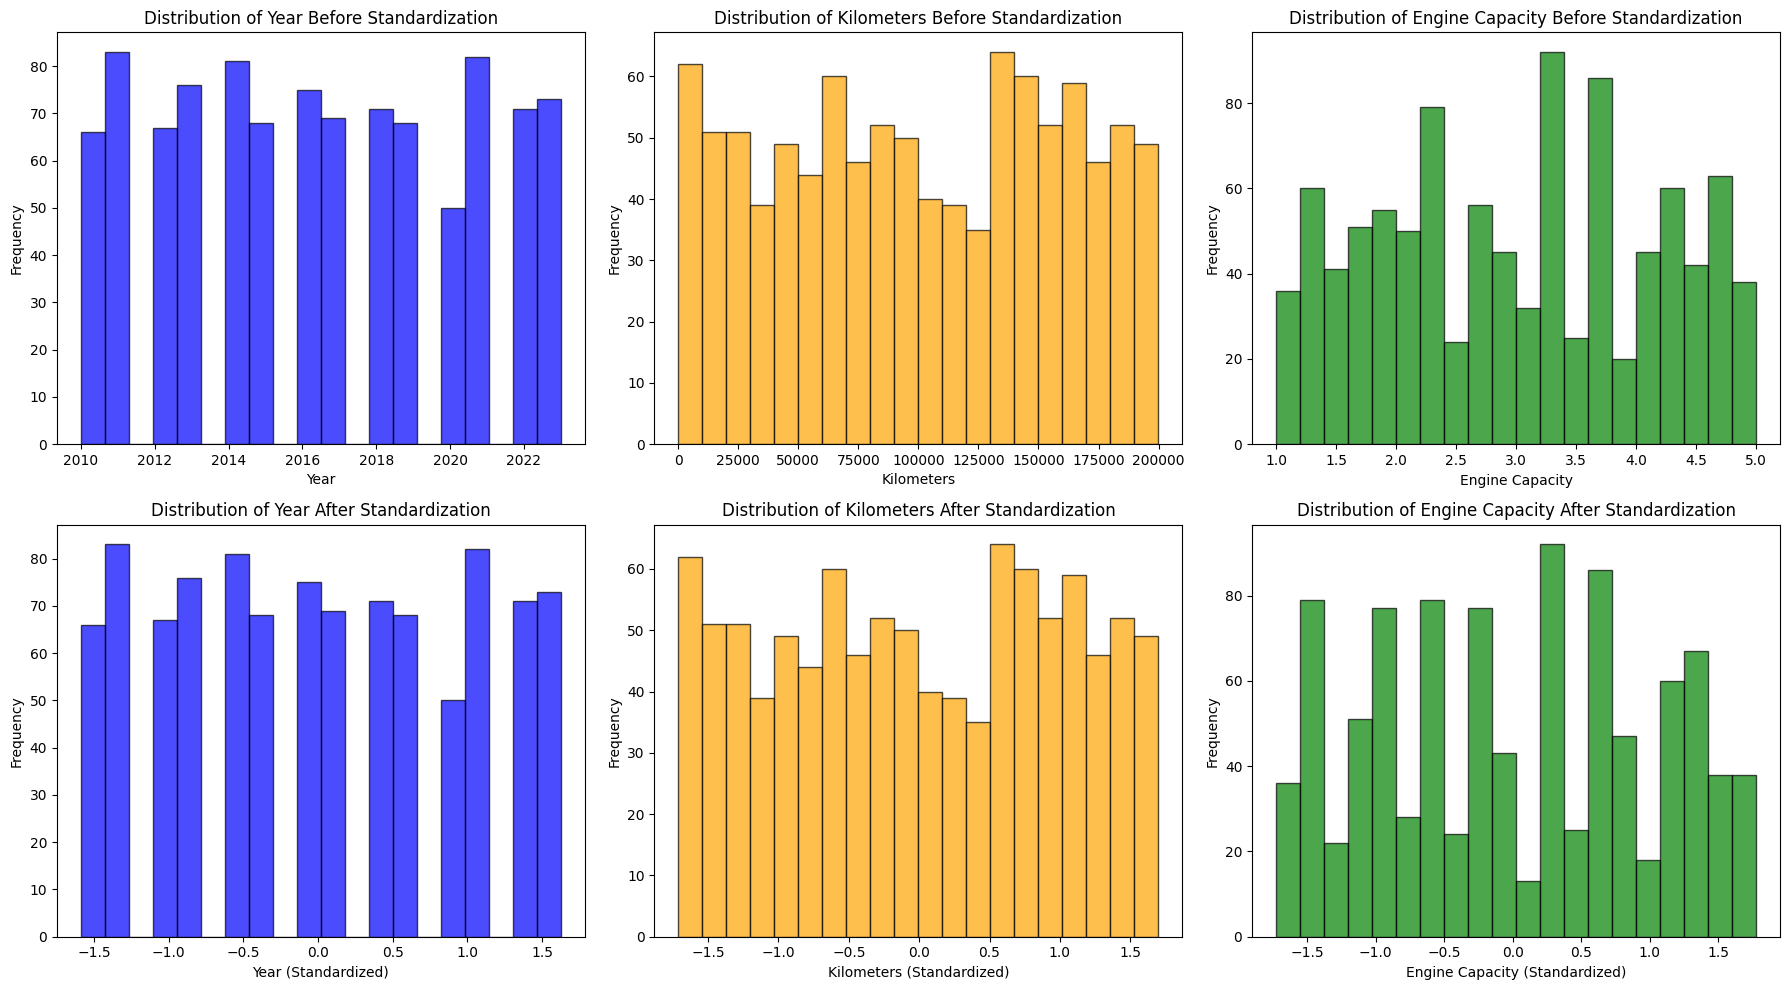

In [ ]:
# Store original values for plotting
original_year = X['year'].values
original_kilometers = X['kilometers'].values
original_engine_capacity = X['engine_capacity'].values

# For plotting
variables = ['year', 'kilometers', 'engine_capacity']
original_data = [original_year, original_kilometers, original_engine_capacity]
colors = ['blue', 'orange', 'green']
titles = ['Year', 'Kilometers', 'Engine Capacity']
plt.figure(figsize=(18, 10))

# Plot before standardization
for i in range(len(variables)):
    plt.subplot(2, 3, i + 1)
    plt.hist(original_data[i], bins=20, alpha=0.7, color=colors[i], edgecolor='black')
    plt.title(f'Distribution of {titles[i]} Before Standardization')
    plt.xlabel(titles[i])
    plt.ylabel('Frequency')

# Preprocess categorical features
column_transformer = ColumnTransformer(transformers=[
    ('encoder', OneHotEncoder(drop='first'), ['make', 'model', 'color'])], remainder='passthrough')

# Transform the data
X_encoded = column_transformer.fit_transform(X)

# Create a DataFrame from the encoded features
transformed_columns = column_transformer.get_feature_names_out()
df_encoded = pd.DataFrame(X_encoded, columns=transformed_columns)

# Standardize only the numerical features
numerical_features = X[['year', 'kilometers', 'engine_capacity']]
scaler = StandardScaler()
numerical_features_scaled = scaler.fit_transform(numerical_features)

# Convert the scaled numerical features to a DataFrame
df_numerical_scaled = pd.DataFrame(numerical_features_scaled, columns=['year', 'kilometers', 'engine_capacity'])

# Concatenate the one-hot encoded features with the standardized numerical features
df_final = pd.concat([df_encoded, df_numerical_scaled], axis=1)

# Remove any columns that start with "remainder__"
df_final = df_final.loc[:, ~df_final.columns.str.startswith('remainder__')]

# Plot after standardization
for i in range(len(variables)):
    plt.subplot(2, 3, i + 4)
    plt.hist(df_final[variables[i]], bins=20, alpha=0.7, color=colors[i], edgecolor='black')
    plt.title(f'Distribution of {titles[i]} After Standardization')
    plt.xlabel(f'{titles[i]} (Standardized)')
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()


In [ ]:
# Save the transformed DataFrame to an Excel file
output_file = 'transformed_data.xlsx'
df_final.to_excel(output_file, index=False)

# Download the file
files.download(output_file)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**Splitting the data into training and testing datasets**

In [ ]:
X=df_final
# Split the dataset into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Convert the targets to a numpy array (to match input format for TensorFlow)
y_train = np.array(y_train)
y_test = np.array(y_test)

**Defining the neural network architecture**

In [ ]:
# Define the neural network (ANN) model
model = tf.keras.models.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_dim=X_train.shape[1]),  #Input layer
    tf.keras.layers.Dense(32, activation='relu'),  # Hidden layer 1
    tf.keras.layers.Dense(32, activation='relu'),  # Hidden layer 2
    tf.keras.layers.Dense(16, activation='relu'),  # Hidden layer 3
    tf.keras.layers.Dense(16, activation='relu'),  # Hidden layer 4
    tf.keras.layers.Dense(16, activation='relu'),  # Hidden layer 3
    tf.keras.layers.Dense(8, activation='relu'),  # Hidden layer 4
    tf.keras.layers.Dense(1)  # Output layer
])

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mean_squared_error'])

# try increasing and decreasing the number of hidden layers and neurons/hidden layer
# loss='mean_absolute_error'/'mean_squared_error'
# activation='tanh'/'relu'
# metrics=['mean_absolute_percentage_error']/['mean_squared_error']

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


**Training the model**

In [ ]:
# Train the model and store the training history for later visualization
history = model.fit(X_train, y_train, validation_split=0.2, epochs=200, batch_size=32, verbose=1)

Epoch 1/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 33352874.0000 - mean_squared_error: 33352874.0000 - val_loss: 39836616.0000 - val_mean_squared_error: 39836616.0000
Epoch 2/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 37051536.0000 - mean_squared_error: 37051536.0000 - val_loss: 38351820.0000 - val_mean_squared_error: 38351820.0000
Epoch 3/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 36015876.0000 - mean_squared_error: 36015876.0000 - val_loss: 37198808.0000 - val_mean_squared_error: 37198808.0000
Epoch 4/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 34448252.0000 - mean_squared_error: 34448252.0000 - val_loss: 35930996.0000 - val_mean_squared_error: 35930996.0000
Epoch 5/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 30283402.0000 - mean_squared_error: 30283402.0000 - val_loss: 34939912.0000 - val_mean_squared_error: 34939912.0000
Epoch 6/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 29339564.0000 - mean_squared_error: 29339564.0000 - val_loss: 3381

**Plotting the results**

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
R² score on test data: 0.9742


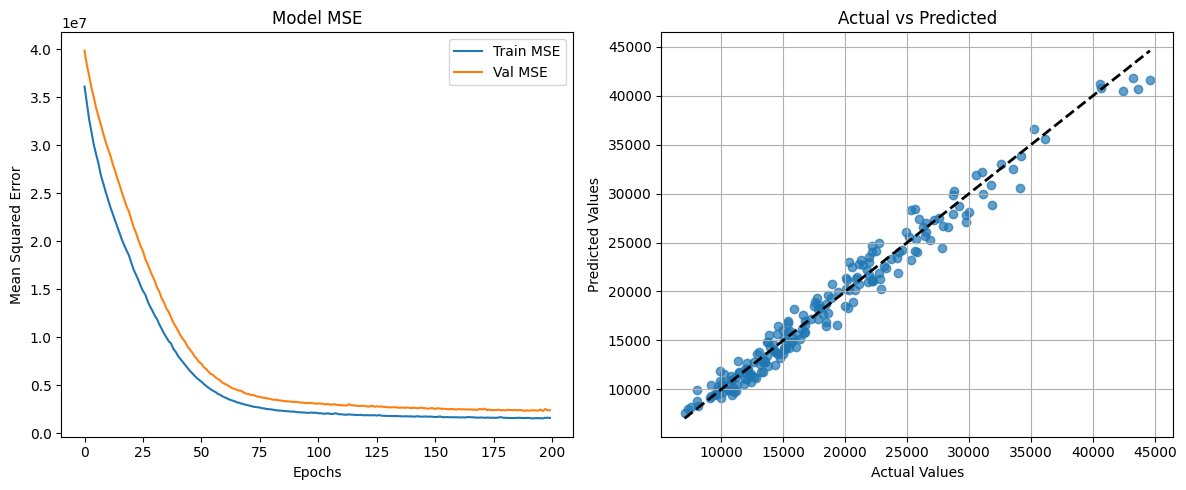

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

# Assuming model has been trained and history is available
# Make predictions on the test set
y_pred = model.predict(X_test)

# R² score for the test data
r2 = r2_score(y_test, y_pred)
print(f"R² score on test data: {r2:.4f}")

# Plot training & validation loss values over epochs
plt.figure(figsize=(12, 5))

# MSE plot
plt.subplot(1, 2, 1)
plt.plot(history.history['mean_squared_error'], label='Train MSE')
plt.plot(history.history['val_mean_squared_error'], label='Val MSE')
plt.title('Model MSE')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error')
plt.legend()

# Actual vs Predicted plot
plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)  # Diagonal line
plt.title('Actual vs Predicted')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.grid()

plt.tight_layout()
plt.show()


# Case Study 2: Industrial dataset

Loading the libraries and uploading the data

In [ ]:
# Loading the libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from google.colab import files

# Allow user to upload an Excel file
uploaded = files.upload()
file_name = list(uploaded.keys())[0]

Saving industrial_dataset.xlsx to industrial_dataset.xlsx


Displaying the first few lines of dataset

In [ ]:
# Load the dataset
df = pd.read_excel(file_name)

# Display the first few rows of the dataset
print(df.head())

  machine_type   material location  shift  process_duration  temperature  \
0        Drill  Composite  Plant D  Night              3.50         33.5   
1   CNC Router  Composite  Plant C  Night              5.53         27.3   
2     Grinding  Composite  Plant D  Night              1.86         27.1   
3   CNC Router  Composite  Plant C    Day              7.22         36.0   
4   CNC Router    Inconel  Plant B    Day              4.52         24.0   

   pressure  energy_consumption  labor_hours  operational_cost  
0      1.98              460.32         2.48      13608.682116  
1      1.65              247.61         3.28      12121.380898  
2      1.93               67.98         4.53      11414.407015  
3      1.30              213.03         4.77      12739.841811  
4      1.78              421.88         3.96      13919.178436  


Preprocessing the data

**Home Assignment:** Define a neural network model to predict the operational cost based on the given inputs after appropriately processing the categorical and numerical responses

Load and prepare data

In [ ]:
# Load the dataset
#df = pd.read_excel("industrial_dataset.xlsx", sheet_name="Sheet1")

# Separate features and target
X = df.drop("operational_cost", axis=1)
y = df["operational_cost"]

# Define categorical and numerical columns
categorical_cols = ["machine_type", "material", "location", "shift"]
numerical_cols = ["process_duration", "temperature", "pressure", "energy_consumption", "labor_hours"]

# Preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(), categorical_cols),
        ("num", StandardScaler(), numerical_cols)
    ])

# Apply transformations
X_processed = preprocessor.fit_transform(X)

Step 3: Split Data into Train/Test Sets

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.2, random_state=42
)

Step 4: Build the ANN Model

In [ ]:
model = Sequential()
model.add(Dense(256, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dense(128, activation='relu'))
model.add(Dense(128, activation='relu'))
#model.add(Dense(128, activation='relu'))
#model.add(Dense(128, activation='relu'))
#model.add(Dense(64, activation='relu'))
#model.add(Dense(64, activation='relu'))
#model.add(Dense(64, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(1, activation='linear'))  # Output layer for regression

Step 5: Compile the Model

In [ ]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mean_squared_error',
    metrics=['mae']
)

Step 6: Train the Model

In [ ]:
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=200,
    batch_size=32,
    verbose=1
)

Epoch 1/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 542353.1875 - mae: 582.8432 - val_loss: 604522.5000 - val_mae: 607.2131
Epoch 2/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 547617.3125 - mae: 591.9833 - val_loss: 605413.8125 - val_mae: 604.2096
Epoch 3/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 541995.5000 - mae: 592.8615 - val_loss: 583545.6875 - val_mae: 606.3565
Epoch 4/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 533758.0625 - mae: 573.3441 - val_loss: 607254.0000 - val_mae: 605.2670
Epoch 5/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 596358.4375 - mae: 616.5536 - val_loss: 612380.8750 - val_mae: 608.0516
Epoch 6/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 551139.1875 - mae: 593.0729 - val_loss: 579837.1875 - val_mae: 606.2977
Epoch 7/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 496848.9688 - mae: 563.7997 - val_loss: 589109.0625 - val_mae: 606.8721
Epoch 8/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 566299.7500 - mae: 61

Step 7: Evaluate the Model

In [ ]:
loss, mae = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss (MSE): {loss:.2f}")
print(f"Test MAE: {mae:.2f}")

Test Loss (MSE): 689150.81
Test MAE: 674.18


Step 8: Make Predictions

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
R² score on test data: 0.9384


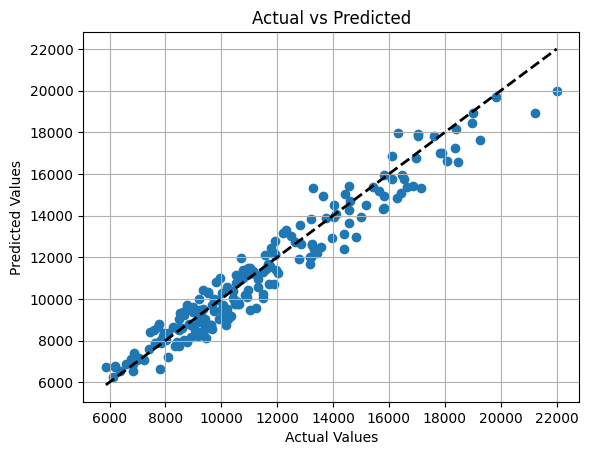

In [ ]:
predictions = model.predict(X_test)

plt.scatter(y_test,predictions)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)  # Diagonal line
plt.title('Actual vs Predicted')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.grid()

# R² score for the test data
r2 = r2_score(y_test, predictions)
print(f"R² score on test data: {r2:.4f}")

#Embeddings

Think of embeddings as a way to represent words or categories as points in space. Each word or category gets a unique position in this space, and similar words/categories are placed closer to each other. For example, if you have words like "cat" and "dog," their embeddings will be similar because they are both animals. On the other hand, "cat" and "car" would be farther apart because they have less in common.

Instead of just using raw numbers or labels (like "cat" = 1, "dog" = 2), embeddings use vectors (e.g., [0.1, -0.3, 0.5]) to capture the meaning or relationships between words or categories.

*  They make it easier for machine learning models to understand relationships between words or categories.
*  Instead of treating every word as a unique, unrelated token, embeddings give a more meaningful representation that the model can work with.

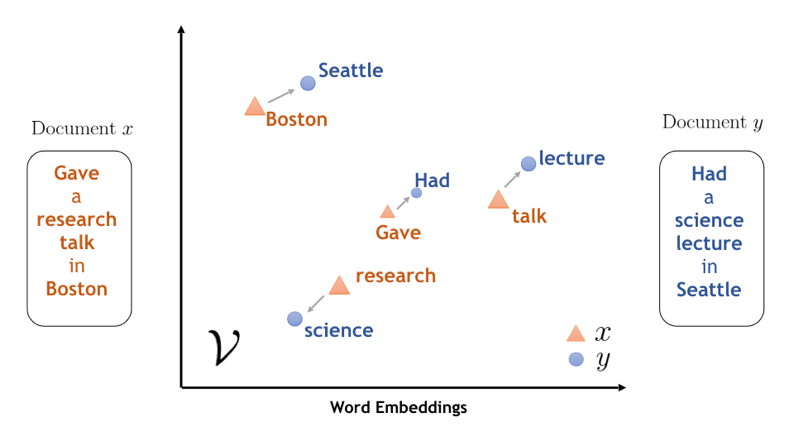

GloVe: Global Vectors for Word Representation developed by Stanford researchers. They are pre-trained word vectors. For further reading, refer: https://nlp.stanford.edu/pubs/glove.pdf

    Wikipedia 2014 + Gigaword 5 (6B tokens, 400K vocab, uncased, 50d, 100d, 200d, & 300d vectors, 822 MB download): glove.6B.zip
    Common Crawl (42B tokens, 1.9M vocab, uncased, 300d vectors, 1.75 GB download): glove.42B.300d.zip
    Common Crawl (840B tokens, 2.2M vocab, cased, 300d vectors, 2.03 GB download): glove.840B.300d.zip
    Twitter (2B tweets, 27B tokens, 1.2M vocab, uncased, 25d, 50d, 100d, & 200d vectors, 1.42 GB download): glove.twitter.27B.zip

Word2Vec: Learns embeddings by predicting a word from its surrounding context (or vice versa) using a shallow neural network.

For both GloVe and Word2Vec embeddings, we need to load the database of vector spaces for millions of words.

BERT: Contextualized embeddings, where the meaning of a word changes based on the context of the entire sentence. For BERT, we just have to load the pre-trained BERT model, and not vector database (non-unique vectors for each words)

In [ ]:
import torch
from transformers import BertTokenizer, BertModel
from sklearn.decomposition import PCA

# Sample sentence
texts = ["machine learning is so much fun"]

# Load pre-trained BERT tokenizer and model
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertModel.from_pretrained('bert-base-uncased')

# Tokenize and encode the texts
inputs = tokenizer(texts, return_tensors='pt', padding=True, truncation=True, max_length=10)

# Get the embeddings (outputs the hidden states for each token)
with torch.no_grad():
    outputs = model(**inputs)

# Extract embeddings from the last hidden layer (shape: [batch_size, sequence_length, hidden_size])
embeddings = outputs.last_hidden_state  # Hidden size for BERT-base is 768 dimensions

# Convert embeddings to NumPy
embeddings_np = embeddings.numpy()

# Flatten the embeddings to a 2D array (combining batch and token dimensions) for PCA
embeddings_flattened = embeddings_np.reshape(-1, embeddings_np.shape[-1])

# Reduce dimensionality to 3 using PCA
pca = PCA(n_components=3)
reduced_embeddings = pca.fit_transform(embeddings_flattened)

# Reshape reduced embeddings back to the original sentence structure
reduced_embeddings = reduced_embeddings.reshape(embeddings_np.shape[0], embeddings_np.shape[1], 3)

# Print the reduced 3D embeddings for each word in the sentences
for i, sentence in enumerate(texts):
    print(f"Sentence {i+1} embeddings:")
    tokens = tokenizer.tokenize(sentence)
    for j, token in enumerate(tokens):
        print(f"{token}: {reduced_embeddings[i][j]}")


Sentence 1 embeddings:
machine: [-10.149453    1.8171885   2.5353246]
learning: [-13.071798    1.2407064   1.7395229]
is: [-1.7733449   0.85513747 -6.315181  ]
so: [ 5.9657326   2.4573905  -0.21940622]
much: [6.3602858 3.268163  4.922576 ]
fun: [7.559432  3.4166214 3.6610236]
